# Resource Estimation for fault-tolerant implementation of QPE

We can now estimate the resources required for a fault-tolerant implementation of QPE for the deduced Hamiltonian. For this, we have to make some assumptions first.
The paper uses a *rotated surface code* for error correction with a certain *code distance* and implements certain gates using lattice surgery and magic states.
They assume a physical error rate of $p = 10^{-3}$ or $p = 10^{-4}$. This refers to the probability of a physical qubit experiencing an error during an operation. Further, they assume a target failure probability of 1% for the entire computation. This means that the probability of the entire quantum computation failing should be less than 1%.
Now, they assume a certain noise model from that we can deduce the probability of a logical error (i.e., an error that occurs to our encoded logical qubits) as a function of the code distance $d$ and the physical error rate $p$. The paper uses the following formula for the logical error rate:
$$
p_L(d, p) = 0.1 \left(100p \right)^{(d+1)/2}
$$

The probability for a logical error to occur during the entire computation is given by:
$$
P_L(d, p) = (n_{data} + n_{route}) \cdot n_{meas} \cdot p_L(d, p)
$$
Here, $n_{data}$ is the number of logical qubits used for data, $n_{route}$ is the number of ancillas we need for lattice surgery and $n_{meas}$ is the number of QEC rounds.
Now, we can solve this for the code distance $d$ given a target failure probability $P_L(d, p) < 0.005$ and a physical error rate $p$. We can then use this code distance to estimate the number of physical qubits required for the computation.

In our case $n_{data}$ is 2 for the iterative QPE approach, $n_{route}$ is also 2 and $n_{meas}$ is a little more complicated to calculate. For that we need to know the total number of gates we have for each gate type and multiply this by the number of QEC rounds needed for each gate type.
These are:
| Logical Gate / Operation | QEC Rounds Formula |
| :--- | :--- |
| **CNOT** | $3d + 4$ |
| **Hadamard ($H$)** | $3d + 4$ |
| **$T$ / $T^\dagger$-like** | $\frac{5d}{2} + 4$ |
| **$S$ / $S^\dagger$** | $\frac{3d}{2} + 3$ |
| **$Z$-basis Measurement** | $1$ |

In [1]:

from generate_qpe import decompose_qpe_with_gridsynth
from generate_qpe import generate_qpe_circuit
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from qutip_qip.circuit import QubitCircuit

# Fixed Circuit Parameters
n_data = 2
n_route = 2
target_error = 0.005


gate_cost = {
    'CNOT': (3, 4),
    'H': (3, 4),
    'T': (2.5, 4),
    'S': (1.5, 3),
    'M': (0, 1),
}

# test circuit
qc=generate_qpe_circuit()
qc_gridsynth=decompose_qpe_with_gridsynth(qc,bits=33)

gate_numbers = dict(Counter(gate.name for gate in qc_gridsynth.gates))
print(gate_numbers)
def n_meas(distance):
    return sum([
        gate_count * (distance * gate_cost[gate][0] + gate_cost[gate][1])
        for gate, gate_count in gate_numbers.items() if gate in gate_cost])


def prob_logical_error(distance, p_e):
    p_L = 0.1 * ((100.0 * p_e) ** ((distance + 1.0) / 2.0))
    return (n_data + n_route) * n_meas(distance) * p_L


@interact(
    p_e=widgets.FloatLogSlider(
        value=1e-3,
        min=-4,
        max=-2.7,
        step=0.05,
        description='p_e:',
        readout_format='.1e',
    )
)
def plot_logical_error(p_e):
    d_min, d_max = 1, 20
    distances = np.arange(d_min, d_max + 1, 2)
    errors = [prob_logical_error(d, p_e) for d in distances]

    plt.figure(figsize=(8, 5))

    # Logical Error Curve
    plt.plot(
        distances,
        errors,
        'o-',
        color='navy',
        linewidth=2,
        label=f'Logical Error ($p_e = {p_e:.1e}$)',
    )

    # Target Budget Line (0.005)
    plt.axhline(
        y=target_error,
        color='crimson',
        linestyle='--',
        linewidth=2,
        label=f'Target Budget ({target_error})',
    )

    plt.yscale('log')
    plt.xticks(distances)
    plt.xlabel('Code Distance ($d$)', fontsize=11)
    plt.ylabel('Total Logical Error Probability', fontsize=11)
    plt.title('Logical Error Probability vs. Code Distance', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(fontsize=10)

    plt.tight_layout()
    plt.show()

/Users/julianlindemann/Documents/Uni/Master/Summer/SCQIS/chem-compilation/.venv/lib/python3.14/site-packages/pygridsynth/gridsynth.py:362: UserWarning: pygridsynth is synthesizing the angle 1.620620405021406. Please verify that this is the intended value. Using float may introduce precision errors; consider using mpmath.mpf for exact precision.
  theta, epsilon = convert_theta_and_epsilon(theta, epsilon, dps=cfg.dps)
/Users/julianlindemann/Documents/Uni/Master/Summer/SCQIS/chem-compilation/.venv/lib/python3.14/site-packages/pygridsynth/gridsynth.py:362: UserWarning: pygridsynth is synthesizing the angle -0.7853981633974483. Please verify that this is the intended value. Using float may introduce precision errors; consider using mpmath.mpf for exact precision.
  theta, epsilon = convert_theta_and_epsilon(theta, epsilon, dps=cfg.dps)
/Users/julianlindemann/Documents/Uni/Master/Summer/SCQIS/chem-compilation/.venv/lib/python3.14/site-packages/pygridsynth/gridsynth.py:362: UserWarning: pygr

{'H': 4025, 'X': 7, 'CNOT': 62, 'T': 3954, 'S': 2178, 'SWAP': 1}


interactive(children=(FloatLogSlider(value=0.001, description='p_e:', max=-2.7, min=-4.0, readout_format='.1e'…

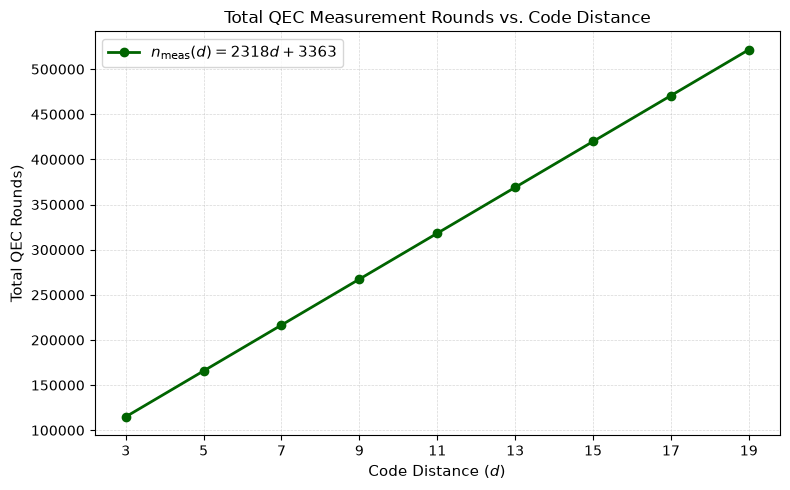

In [2]:
plt.figure(figsize=(8, 5))
distances = np.arange(3, 21, 2)
rounds = [n_meas(d) for d in distances]
plt.plot(
    distances,
    rounds,
    'o-',
    color='darkgreen',
    linewidth=2,
    label=r'$n_{\mathrm{meas}}(d) = 2318d + 3363$',
)

plt.xticks(distances)
plt.xlabel('Code Distance ($d$)', fontsize=11)
plt.ylabel('Total QEC Rounds)', fontsize=11)
plt.title('Total QEC Measurement Rounds vs. Code Distance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

To calculate the number of physical qubits we need, we need to know the number of logical qubits we need for the computation and the number of qubits we need for routing. Each logical qubit is encoded in the rotated surface code, which requires $d^2$ physical qubits for the data and $d^2-1$ physical qubits as ancillas for stabilizer measurements. However, for lattice surgery we need to reserve some extra qubits for merging.
One possible layout is thus to have a block of $(d+1)^2$ ancilla qubits and $d^2$ data qubits for each logical qubit and in between another line of data qubits for lattice surgery, so for $n_{data}=3$ and $n_{meas}=1$, we get:
$$n_{p\_qub} = (3+1) \cdot (d+1)^2 + (3+1) * (d^2 + d)$$

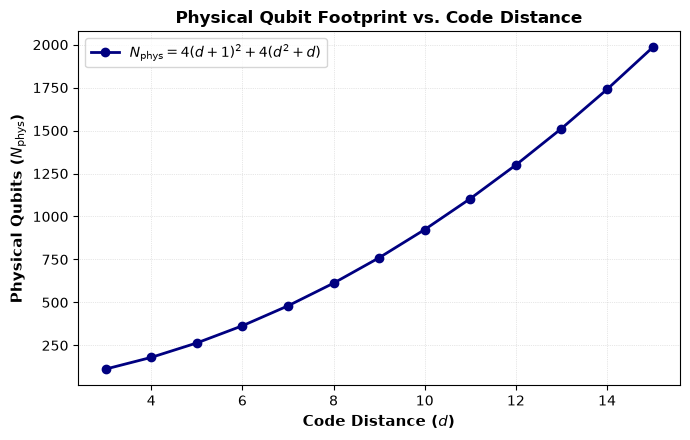

In [6]:
# Define distance range (d=3 to d=15)
d = np.arange(3, 16)

# Physical qubit formula: 4*(d+1)^2 + 4*(d^2 + d)
N_phys = 4 * (d + 1)**2 + 4 * (d**2 + d)

# Create the plot
plt.figure(figsize=(7, 4.5))

plt.plot(d, N_phys, color='navy', marker='o', linewidth=2, label=r'$N_{\mathrm{phys}} = 4(d+1)^2 + 4(d^2 + d)$')

plt.xlabel('Code Distance ($d$)', fontsize=11, fontweight='bold')
plt.ylabel('Physical Qubits ($N_{\\mathrm{phys}}$)', fontsize=11, fontweight='bold')
plt.title('Physical Qubit Footprint vs. Code Distance', fontsize=12, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

What we didn't mention so far is that implementing the $T$ gate is actually more complicated. The Eastin-Knill Theorem tells us that there is no QECC that can implement a universal gate set transversally. In the case of the rotated surface code, we can implement the Clifford gates transversally (or with lattice surgery), but not the $T$ gate. An often used strategy for this is magic state injection and distillation which comes from gate teleportation. Here, the underlying idea is that we use quantum teleportation (which you might remember) and then conjugate the Pauli correction we usually do by the $T$ gate, so instead of $P$, we do $TPT^{\dag}$. If we now apply a $T$ gate to our second qubit of the Bell pair, the $TT^\dag$ cancels and we are left with the Pauli correction and applying the $T$ gate to the state we teleported. The cool thing about this is now that by conjugating the Pauli by the $T$ gate we actually obtain a Clifford gate we can implement transversally again. So, we reduced the task to preparing a state by applying a $T$ gate which is easier because it is a *known* state and applying a usual Clifford gate.
A compressed version (without using the Bell pair required for quantum teleportation) looks like this:

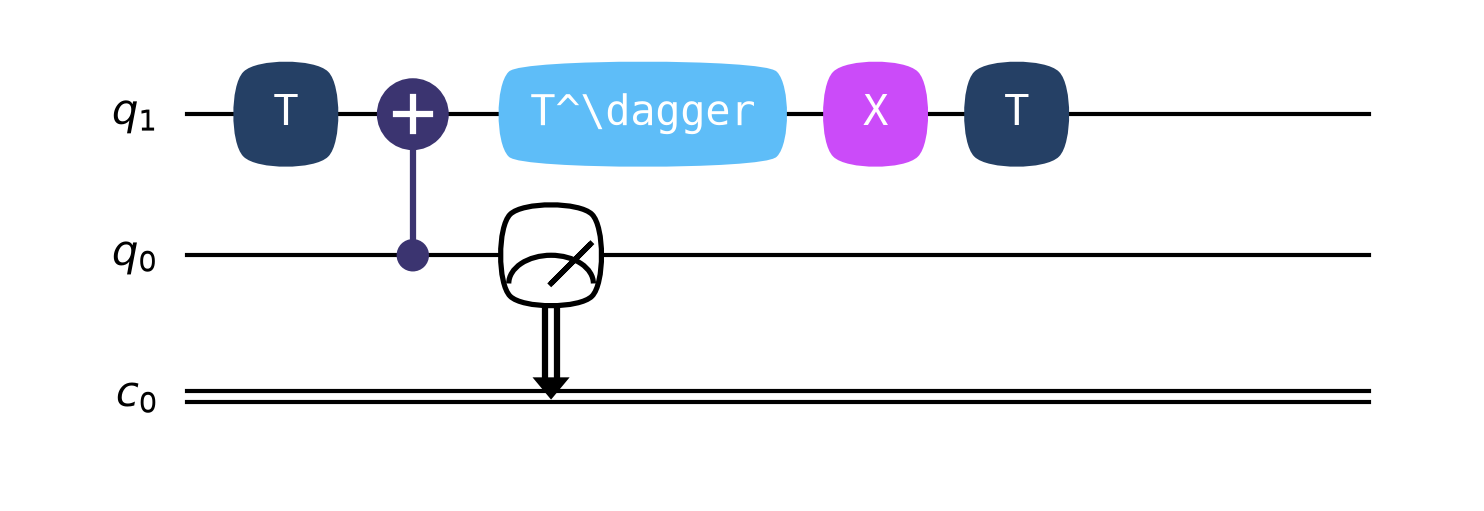

Ancilla Density Matrix:
 Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5       +0.j         0.35355339-0.35355339j]
 [0.35355339+0.35355339j 0.5       +0.j        ]]


In [3]:
import qutip_qip.operations
import matplotlib.pyplot as plt
import numpy as np
import qutip as q
from qutip_qip.circuit import QubitCircuit

# 1. Instantiate Circuit (2 qubits, 1 classical bit)
qc = QubitCircuit(N=2, num_cbits=1)
# Step A: Magic state preparation on Ancilla (Qubit 1)
qc.add_gate("T", targets=[1])

# Step B: Entangle Data (Qubit 0) and Ancilla (Qubit 1)
qc.add_gate("CNOT", controls=[0], targets=[1])

# Step C: Measure Data Qubit in Z-basis
qc.add_measurement("M0", targets=[0], classical_store=0)

# Step D: Explicit T X T† sequence on Ancilla (Qubit 1)
# 1. T dagger (T†)
qc.add_gate("RZ", targets=[1], arg_value=-np.pi / 4, arg_label=r"T^\dagger")

# 2. Controlled X (triggered if measurement outcome is 1)
qc.add_gate("X", targets=[1], classical_controls=[0]) # Controlled by measurement outcome

# 3. T gate
qc.add_gate("T", targets=[1])

qc.draw("matplotlib", dpi=300)
plt.show()

plus = (q.basis(2, 0) + q.basis(2, 1)).unit()
psi_in = q.tensor(plus, plus)

final_state = qc.run(state=psi_in)
rho_ancilla = final_state.ptrace(1)
print("Ancilla Density Matrix:\n", rho_ancilla)



The prepared state is called a *magic state* or just $|T\rangle$ and can be seen as a resource we need for every $T$ gate we want to apply.

This prepared state $T|+\rangle=|T\rangle$ can be seen as a resource that is necessary for every $T$ gate we want to apply. So, the question is how we can generate these states fault-tolerantly? This procedure is known as *magic state distillation* and there are many different protocols for it. The basic idea is always the following: We take some imperfect magic states as an input and do some operations and obtain less but better-quality magic states as an output.
One possible protocol for this a 15-to-1 protocol using a Reed-Muller code.
The idea is to take yet another QECC (that is independent of the one we use for error correction) that has a transversal version of the gate we want to implement. Note that this is not contradicting the Eastin-Knill Theorem, as this doesn't say there is no QECC with a transversal $T$ gate, just not for a whole universal gate set.
Now, we first prepare a logical $|+\rangle$ state of the Reed-Muller code and then apply the transversal $T$ gate to it. Each of the physical $T$ gates has some error probability $p$ and as the Reed-Muller code has distance 3 and we are concerned with state preparation, we can detect up to 2 errors. So, we only fail if 3 or more errors occur, which happens with probability $O(p^3)$. We then measure the stabilizers of the Reed-Muller code and if we detect an error, we discard the state and start over. If we don't detect an error, we can decode the state and obtain a logical $|T\rangle$ state.
A circuit for this looks like this:

That being said, in the paper they use a more efficient implementation of this that I was not able to understand (https://arxiv.org/abs/1905.06903).
To do a resource estimation we need to consider how many magic states we need and how much error we have left from our target failure probability. This was one half of 1%, so we have $m \cdot p_{L, T} < 0.005$ where $m$ is the number of $T$ gates we need and $p_{L, T}$ is the logical error rate of the magic state distillation protocol. From this bound, they then choose a distillation protocol that has a logical error rate that is small enough to satisfy this bound.